<a href="https://colab.research.google.com/github/vinayak10M/DSA_Case_Study/blob/main/CaseStudy_UnSupervised_Learning_Vinayak_AR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df = pd.read_csv('/content/drive/MyDrive/DSA/Casestudy_Unsupervised_Learning/adult_dataset.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [35]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [36]:
df = df.replace('?',pd.NA)

In [37]:
df.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [38]:
df['age'] = df['age'].fillna(df['age'].mean())
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].mean())
df['native-country'] = df['native-country'].fillna(df['native-country'].mode()[0])

In [39]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [40]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [41]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [42]:
#Outliers

num_columns = ['age', 'fnlwgt', 'education-num', 'hours-per-week']
Q1 = df[num_columns].quantile(0.25)
Q3 = df[num_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

age                   28.0
fnlwgt            117555.0
education-num          9.0
hours-per-week        40.0
Name: 0.25, dtype: float64 age                   47.0
fnlwgt            237620.0
education-num         12.0
hours-per-week        45.0
Name: 0.75, dtype: float64 age                   19.0
fnlwgt            120065.0
education-num          3.0
hours-per-week         5.0
dtype: float64 age                  -0.5
fnlwgt           -62542.5
education-num         4.5
hours-per-week       32.5
dtype: float64 age                   75.5
fnlwgt            417717.5
education-num         16.5
hours-per-week        52.5
dtype: float64


In [43]:
#Handling Outliers
df[num_columns] = df[num_columns].clip(lower_bound, upper_bound, axis=1)

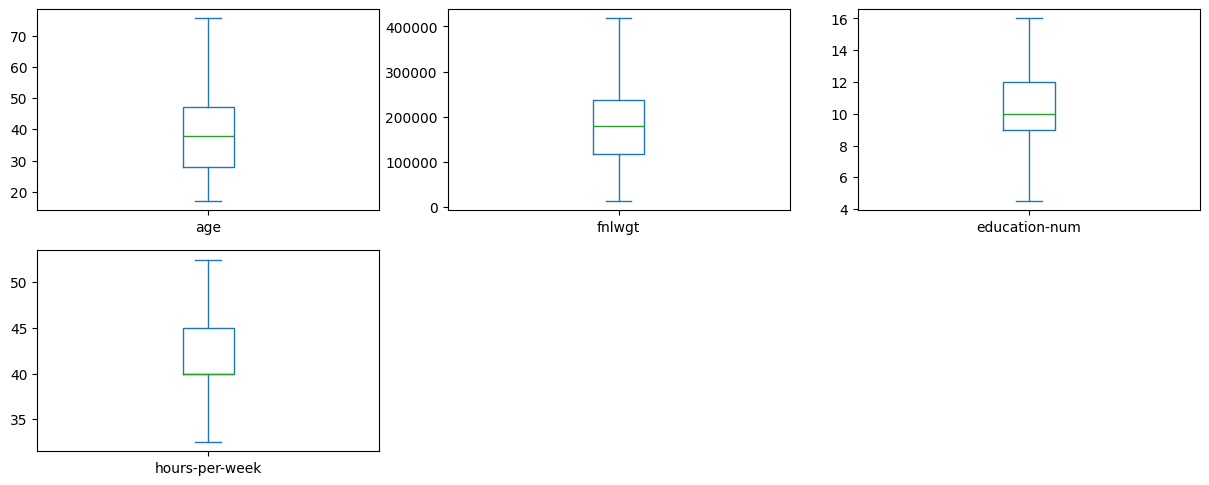

In [44]:
df[num_columns].plot(
    kind='box',
    subplots=True,
    layout=(4, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)
plt.show()

In [45]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [46]:
df['income'].value_counts()

,count
income,
<=50K,24706
<=50K.,12430
>50K,7839
>50K.,3846


In [47]:
df = df.drop(columns=['education'])

In [48]:
df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()
print(df['income'].value_counts())

income
<=50K    37136
>50K     11685
Name: count, dtype: int64


In [49]:
# 1. Strip spaces from 'sex' just to be safe, exactly like you did for income
df['sex'] = df['sex'].str.strip()

# 2. Map both columns using keys with NO leading spaces
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# 3. Apply the One-Hot Encoding
cols_to_encode = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

df.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516.0,13.0,1,2174,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311.0,13.0,1,0,0,32.5,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646.0,9.0,1,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721.0,7.0,1,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409.0,13.0,0,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


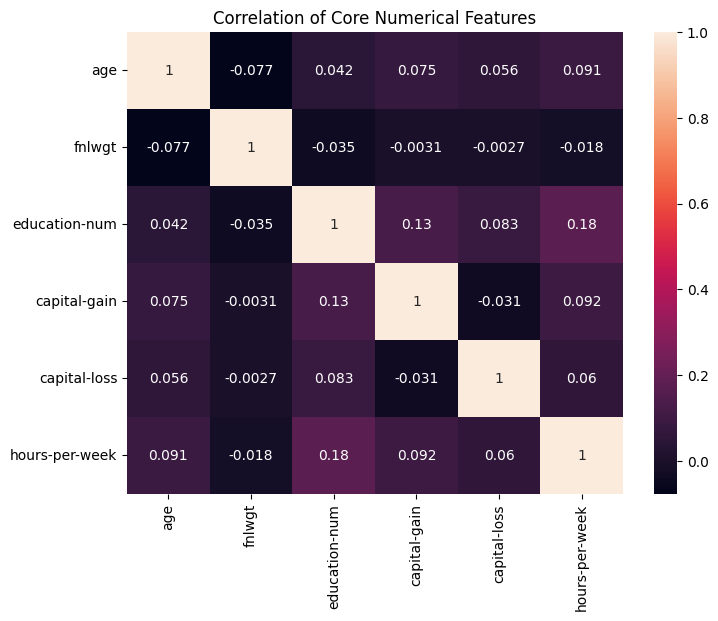

In [50]:
core_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
core_corr = df[core_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(core_corr, annot=True)
plt.title("Correlation of Core Numerical Features")
plt.show()

<Axes: xlabel='age', ylabel='Count'>

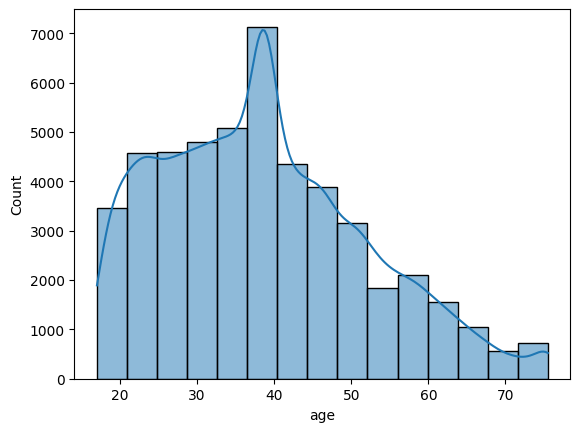

In [51]:
sns.histplot(df['age'],bins=15, kde=True)

In [52]:
x = df[['age','hours-per-week']]
x.head()

,age,hours-per-week
0,39.0,40.0
1,50.0,32.5
2,38.0,40.0
3,53.0,40.0
4,28.0,40.0


<Axes: xlabel='capital-gain', ylabel='capital-loss'>

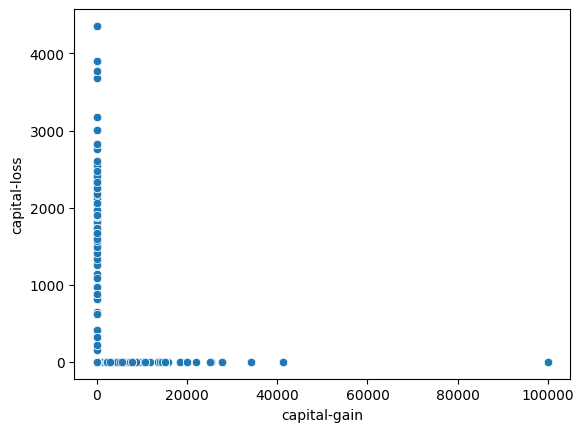

In [53]:
sns.scatterplot(data=df , x='capital-gain', y='capital-loss')

In [54]:
df.columns

Index(['age', 'fnlwgt', 'education-num', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'relationship_Not-in-family',
       'relationsh

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd


In [56]:
# 1. Separate features (X) from the target variable (y)
X = df.drop('income', axis=1)
y = df['income']

# 2. Standardize the full feature set
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA (retaining 95% of the variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features (95% variance): {X_pca.shape[1]}")

# 4. Create a new DataFrame with the reduced principal components
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

# Re-attach the target variable for future modeling
df_pca['income'] = y.values

df_pca.head()

Original number of features: 82
Reduced number of features (95% variance): 70


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,PC70,income
0,0.014425,1.069012,-2.027745,1.868173,-0.600459,-1.644467,-0.656019,-0.387871,-0.928844,-0.389715,...,-0.247032,0.297796,0.220271,-0.021889,0.312538,0.697698,0.064016,-0.815065,-0.720936,0
1,2.858252,0.132140,-0.891436,0.511830,-0.042957,-1.252137,0.077685,1.468650,1.150430,0.374058,...,0.690709,-0.260138,-0.185082,0.858130,-0.717522,0.461320,-1.980100,1.185290,-0.837979,0
2,-0.619957,0.870407,1.046229,-0.238433,-0.156553,0.044576,-1.215711,-0.463985,-1.028832,-0.399870,...,-1.206230,-0.526532,-0.102669,0.265793,-0.155586,0.160605,-0.050308,-0.727818,0.875227,0
3,-0.325688,-1.487264,0.532200,-1.968691,3.466648,0.342842,-0.559272,-0.811022,-0.292901,0.285025,...,-0.612235,-0.771271,-0.027599,-0.601080,0.085698,-0.308315,-0.177121,-0.834792,-0.248380,0
4,-0.635278,-4.380400,-0.595238,-0.754512,-0.529585,0.851816,3.655222,-3.426569,2.535885,1.234186,...,1.037521,0.843717,-0.779926,-2.665079,2.191163,1.254529,1.582686,-1.577663,-0.582790,0


In [57]:
x = df_pca[['PC1', 'PC2']]
x.head()

,PC1,PC2
0,0.014425,1.069012
1,2.858252,0.132140
2,-0.619957,0.870407
3,-0.325688,-1.487264
4,-0.635278,-4.380400


<Axes: xlabel='PC1', ylabel='PC2'>

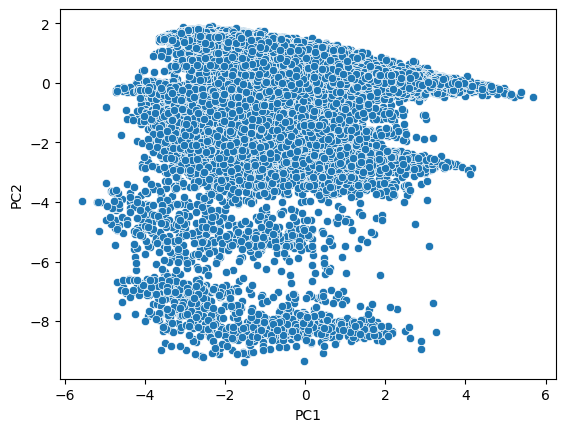

In [58]:
sns.scatterplot(data=df_pca , x='PC1', y='PC2')

KMeans Clustering

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 11):
    km_object = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )
    km_object.fit(x)
    wcss.append(km_object.inertia_)

    # ADD sample_size HERE to speed up the calculation
    score = silhouette_score(x, km_object.labels_, sample_size=5000, random_state=0)

    print(f'{i} clusters - Silhouette Score: {score:.4f}')

2 clusters - Silhouette Score: 0.4772
3 clusters - Silhouette Score: 0.5269
4 clusters - Silhouette Score: 0.5374
5 clusters - Silhouette Score: 0.4433
6 clusters - Silhouette Score: 0.4781
7 clusters - Silhouette Score: 0.4638
8 clusters - Silhouette Score: 0.4626
9 clusters - Silhouette Score: 0.4335
10 clusters - Silhouette Score: 0.4261


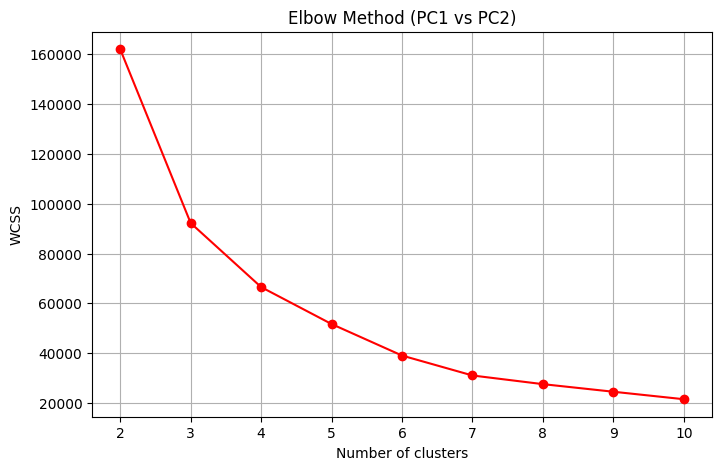

In [60]:
# Plot Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, c='red', marker='o')
plt.title('Elbow Method (PC1 vs PC2)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [61]:
wcss

[161990.75555579236,
 92224.93232448258,
 66527.59920043535,
 51698.46698418485,
 39043.8318005841,
 31046.797379171407,
 27570.426143926885,
 24522.491962572523,
 21520.382278667203]

In [62]:
km_object = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=0
)
km_object.fit(x)

kmeans_cluster_labels = km_object.labels_
kmeans_cluster_labels

array([1, 0, 1, ..., 0, 3, 0], dtype=int32)

In [63]:
df['kmeans_cluster'] = kmeans_cluster_labels
df.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,kmeans_cluster
0,39.0,77516.0,13.0,1,2174,0,40.0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,50.0,83311.0,13.0,1,0,0,32.5,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38.0,215646.0,9.0,1,0,0,40.0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,53.0,234721.0,7.0,1,0,0,40.0,0,0,0,...,0,0,0,0,0,0,1,0,0,3
4,28.0,338409.0,13.0,0,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [64]:
df_pca['kmeans_cluster'] = kmeans_cluster_labels

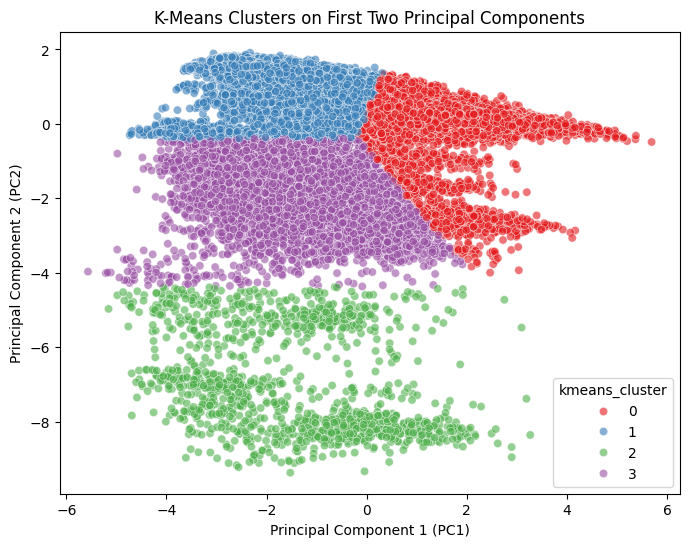

In [65]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='kmeans_cluster',
    palette='Set1',
    alpha=0.6
)
plt.title('K-Means Clusters on First Two Principal Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.show()

In [66]:
# 1. Attach cluster labels to original and PCA data
df['kmeans_cluster'] = df_pca['kmeans_cluster'].values

# 2. Inspect cluster centroids in PCA space
print("--- PCA Space Centroids ---")
print(df_pca.groupby('kmeans_cluster')[['PC1', 'PC2']].mean())

# 3. Inspect demographic breakdown across clusters
print("\n--- Original Feature Means per Cluster ---")
print(df.groupby('kmeans_cluster')[['age', 'hours-per-week', 'education-num', 'income']].mean())

--- PCA Space Centroids ---
                     PC1       PC2
kmeans_cluster                    
0               1.596462  0.125274
1              -1.436653  0.993422
2              -1.393886 -6.982338
3              -1.398829 -1.774973

--- Original Feature Means per Cluster ---
                      age  hours-per-week  education-num    income
kmeans_cluster                                                    
0               44.165267       43.173103      10.588668  0.433721
1               31.653008       39.057653       9.867026  0.040353
2               38.836483       40.726955      10.543546  0.242613
3               38.133777       39.873766       9.105323  0.100698


:Hierarchical Clustering (Aglomerative Clustering)

In [67]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

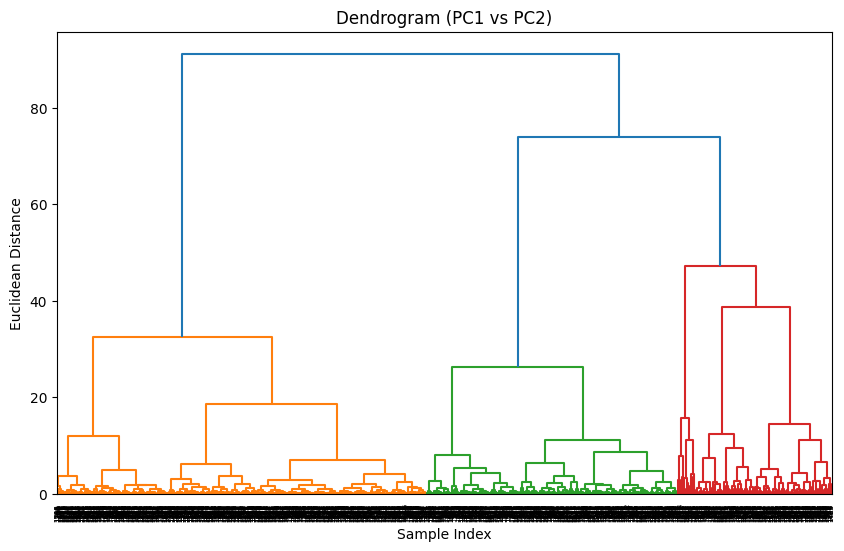

In [68]:
# Subset for hierarchical clustering
x_sample = x.iloc[:2000]

# Dendrogram
mergings = linkage(x_sample, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(mergings)
plt.title('Dendrogram (PC1 vs PC2)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()

In [69]:
# Fit Agglomerative Clustering
ac_obj = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
ac_clusters = ac_obj.fit_predict(x_sample)
print("Silhouette Score (Agglomerative):", silhouette_score(x_sample, ac_clusters))

Silhouette Score (Agglomerative): 0.5135710371287021


DBSCAN

In [70]:
from sklearn.cluster import DBSCAN

# Fit DBSCAN on PC1 and PC2
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(x)

In [71]:
df_pca['Cluster_db'] = labels
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC64,PC65,PC66,PC67,PC68,PC69,PC70,income,kmeans_cluster,Cluster_db
0,0.014425,1.069012,-2.027745,1.868173,-0.600459,-1.644467,-0.656019,-0.387871,-0.928844,-0.389715,...,0.220271,-0.021889,0.312538,0.697698,0.064016,-0.815065,-0.720936,0,1,0
1,2.858252,0.132140,-0.891436,0.511830,-0.042957,-1.252137,0.077685,1.468650,1.150430,0.374058,...,-0.185082,0.858130,-0.717522,0.461320,-1.980100,1.185290,-0.837979,0,0,0
2,-0.619957,0.870407,1.046229,-0.238433,-0.156553,0.044576,-1.215711,-0.463985,-1.028832,-0.399870,...,-0.102669,0.265793,-0.155586,0.160605,-0.050308,-0.727818,0.875227,0,1,0
3,-0.325688,-1.487264,0.532200,-1.968691,3.466648,0.342842,-0.559272,-0.811022,-0.292901,0.285025,...,-0.027599,-0.601080,0.085698,-0.308315,-0.177121,-0.834792,-0.248380,0,3,0
4,-0.635278,-4.380400,-0.595238,-0.754512,-0.529585,0.851816,3.655222,-3.426569,2.535885,1.234186,...,-0.779926,-2.665079,2.191163,1.254529,1.582686,-1.577663,-0.582790,0,2,0


In [72]:
# Value counts per cluster (-1 represents noise)
print(df_pca['Cluster_db'].value_counts())

Cluster_db
 0    47831
 1      808
-1      164
 2       10
 3        8
Name: count, dtype: int64


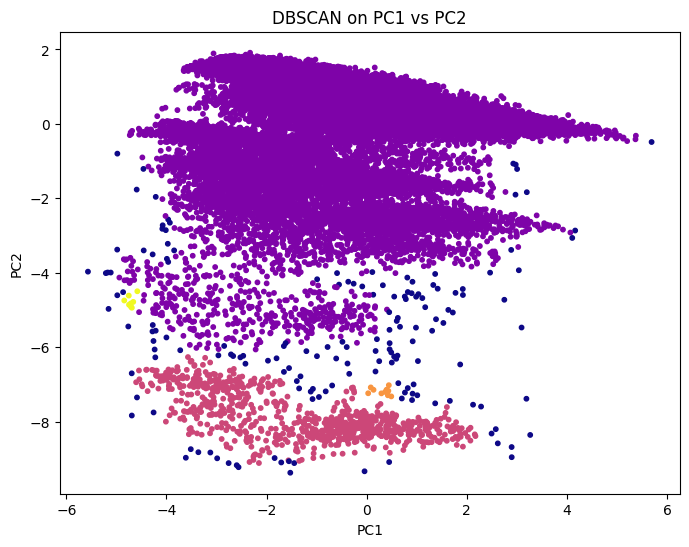

In [73]:
# Plot DBSCAN clusters
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster_db'], cmap='plasma', s=10)
plt.title('DBSCAN on PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()